# Autoencoders, GANs, Diffusion

Autoencoders: learn dense representations of input data: called **latent representations**
- Without any supervision
- Good for anomaly detection, pretraining of LLMs, generating new data (some of them)

General Adversarial Networks (GANs): Generate very convincing fake data
- Super Resolution (increase image res)
- Colorization
- Image gen

Diffusion Models -> have been replacing GANs -> easier to train, slower to run

All of these are unsupervised, learn latent representations, and can generate, but they work very differently
- Autoencoders
    - Learn to copy inputs to outputs 
    - Constraining them helps them learn better ways to copy nontrivially
- GANs
    - 2 neural nets: a generator and a discriminator
        - Generator: generate similar data to training set
        - Discriminator: tell real from fake
    - The generator and discriminator compete turning training (adversarial training)
- Diffusion
    - Gradually remove noise from an image

## PCA w/ Undercomplete Autoencoder

If an autoencoder uses linear activations, MSE cost function, then its just PCA

In [2]:
import torch
import torch.nn as nn

device = "cuda:0"
torch.manual_seed(42)
encoder = nn.Linear(3, 2)
decoder = nn.Linear(2, 3)
autoencoder = nn.Sequential(encoder, decoder).to(device)

This does all the same stuff that PCA in Ch7 did. For example, if you are going 3D->2D, itll find the plane that preserves the most variance

## Stacked Autoencoders
An autoencoder with >1 layer

Obviously more stacking means more powerful, but you also run the risk of overfitting to the training set if it has enough parameters to memorize the training set

Typically, any stacked autoencoder is symmetric. For example, 784 input neurons -> 128 -> 32 -> 128 -> 784. The encodings are the ones AFTER 32

### In Pytorch

In [3]:
stacked_encoder = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
    nn.Linear(128, 32), nn.ReLU(),
) # this layout is for mnist, but you can change it for whatever dataset
stacked_decoder = nn.Sequential(
    nn.Linear(32, 128), nn.ReLU(),
    nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(), # the sigmoid is for outputs -> you want greyscale values btwn 0 and 1 for mnist
    nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
)
stacked_autoencoder = nn.Sequential(stacked_encoder, stacked_decoder).to(device)

Training this shows very lossy/blurry reconstructions as the output

You could train for longer or make the model bigger

### Anomaly Detection w Autoencoders

Just calculate the reconstruction loss between some image and the output. For example, an industrial process where you make square boxes. A bad box might get ripped in half, and not be in the training set, and the model might reconstruct it as fully intact - thus loss high.

### Visualizing Autoencoder Output

Generally, an autoencoder that goes down to 2 or 3 dimensions wont be useful - but you can take one that goes down to 32-dim and use something like t-SNE to visualize

In [4]:
from sklearn.manifold import TSNE

# with torch.no_grad():
#     X_valid_compressed = stacked_encoder(X_valid.to(device))

# tsne = TSNE(init="pca", learning_rate="auto", random_state=42)
# X_valid_2D = tsne.fit_transform(X_valid_compressed.cpu())

### Unsupervised Pretraining Using Stacked Autoencoders

Common technique for low-data supervised tasks is to find a similar model and reuse its lower layers -> similar idea w autoencoders

1) train a stacked autoencoder on all your data.
2) reuse the lower layers as the start to a neural net
3) potentially freeze the kept layers when training the new head


### Tying Weights

To prevent overfitting, you tie the weights of the encoder and decoder. Halves the parameter count, speeds up training

In [5]:
import torch.nn.functional as F

class TiedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Linear(1 * 28 * 28, 128)
        self.enc2 = nn.Linear(128, 32)
        self.dec1_bias = nn.Parameter(torch.zeros(128))
        self.dec2_bias = nn.Parameter(torch.zeros(1 * 28 * 28))

    def encode(self, X):
        Z = X.view(-1, 1 * 28 * 28)  # flatten
        Z = F.relu(self.enc1(Z))
        return F.relu(self.enc2(Z))

    def decode(self, X):
        Z = F.relu(F.linear(X, self.enc2.weight.t(), self.dec1_bias))
        Z = F.sigmoid(F.linear(Z, self.enc1.weight.t(), self.dec2_bias))
        return Z.view(-1, 1, 28, 28)  # unflatten

    def forward(self, X):
        return self.decode(self.encode(X))

### Training one Autoencoder at a time

'Greedy layerwise training'

Train a shallow autoencoder, then encode your whole dataset. Then train another shallow autoencoder on the encoded dataset, and encode again. Repeat.

Your end model is just all the encoders sandwiched together into one model -> think gradient boosting in tabular ML, underfit a bunch until it gets close

## Convolutional Autoencoders

CNNs generally better than FFNs for images 

Encoder: CNN with convolutional layers and pooling layers, reduces the spatial dimensionality of the inputs

Decoder: Increase spatial dimension, reduce depth (just a reverse CNN)



In [6]:
conv_encoder = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),  # output: 16 × 14 × 14
    nn.Conv2d(16, 32, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),  # output: 32 × 7 × 7
    nn.Conv2d(32, 64, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),  # output: 64 × 3 × 3
    nn.Conv2d(64, 32, kernel_size=3, padding="same"), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten())  # output: 32

conv_decoder = nn.Sequential(
    nn.Linear(32, 16 * 3 * 3),
    nn.Unflatten(dim=1, unflattened_size=(16, 3, 3)),
    nn.ConvTranspose2d(16, 32, kernel_size=3, stride=2), nn.ReLU(),
    nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1,
                       output_padding=1), nn.ReLU(),
    nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1,
                       output_padding=1), nn.Sigmoid())

conv_ae = nn.Sequential(conv_encoder, conv_decoder).to(device)

I imagine weight tying might also make sense here, wasnt mentioned. RNNs also possible

## Denoising Autoencoders

Add noise to the inputs and train a model to recover the original image

Could be gaussian noise, could be randomly switched off inputs like dropout

Dropout version: 

In [7]:
dropout_encoder = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(0.5),
    nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
)
dropout_decoder = nn.Sequential(
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
)
dropout_ae = nn.Sequential(dropout_encoder, dropout_decoder).to(device)

## Sparse Autoencoders

Often, sparser networks do better. Add penalties to the cost function that encourage a model to use less active neurons

Basic approach: use sigmoid activation function in coding layer (forces coding values btwn 0-1), use a large coding layer, and l1 regularization to their activations. Your new loss is a combination of the l1 and reconstruction loss

Another way: measure of the 'mean sparsity' of each neuron in the coding layer, across each batch, and penalize the model when mean sparsity differs from some target (for example: mean sparsity = 0.1 means its avg activation is 0.1, and if you see its really 0.3, its too high)

**Kullback-Leibler (KL) Divergence** : Stronger gradients than MSE
- Given two discrete probability distributions, P, Q, KL divergence is given by:
$$ D_{KL} (P || Q) = \sum_i P(i) \log \dfrac{P_(i)}{Q(i)}$$

In this case: we want the divegence between p (target prob a neuron in the coding layer will activate), and q (the actual prob), so KL =
$$ D_{KL} (P || Q) = p \log \dfrac{p}{q} + (1-p) \log \dfrac{1-p}{1-q}$$

In PyTorch, you just need to make sure autoencoder outputs reconstructions and encodings

In [8]:
from collections import namedtuple

AEOutput = namedtuple("AEOutput", ["output", "codings"])

class SparseAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.Sigmoid())
        self.decoder = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
            nn.Unflatten(dim=1, unflattened_size=(1, 28, 28)))

    def forward(self, X):
        codings = self.encoder(X)
        output = self.decoder(codings)
        return AEOutput(output, codings)

Note: training and eval functions may need some tweaking to support predictions

The loss function for sparse ae's:

In [ ]:
def mse_plus_sparsity_loss(y_pred, y_target, target_sparsity=0.1, kl_weight=1e-3, eps=1e-8):
    p = torch.tensor(target_sparsity, device=y_pred.codings.device)
    q = torch.clamp(y_pred.codings.mean(dim=0), eps, 1 - eps)  # actual sparsity
    kl_div = p * torch.log(p / q) + (1 - p) * torch.log((1 - p) / (1 - q))
    return mse(y_pred.output, y_target) + kl_weight * kl_div.sum()

Sparse AE's often give more interpretable encoding -> for example looking for images that get a high value of the first encoding value will give similar images

## Variational Autoencoders

VAEs are probabilistic autoencoders: the outputs are partly random, EVEN AFTER TRAINING
- They are generative autoencoders, meaning they can make new instances that look like training instances

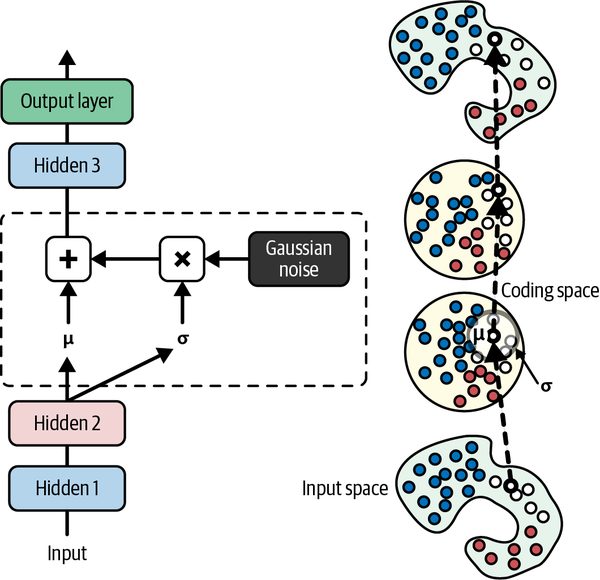

A VAE produces two things: 
- Mean encoding (mu) and standard deviation (sigma)
- Then an encoding gets sampled randomly using mu and sigma

Even if the inputs come from a weird distribution, a VAE tends to produce gaussian-looking samples
- The cost function pushes the encodings to look more gaussian inside of the encoding (or latent) space

HOWEVER: sampling from a random distrbution is not differentiable. So...backpropagation how?
- Reparameterization trick
    - Sample $\epsilon$ from N(0,1), compute mu + sigma*epsilon to model N(mu, sigma^2).
    - Gives you gradients thru mu and sigma

Cost function is a two-parter:
- reconstruction loss as above
- latent loss: pushes autoencoder to have gaussian looking encodings
    - KL divergences between actual distribution and gaussian

$$ L = -\frac{1}{2} \sum_{i=1}^{n}[1+\log{\sigma _i^2} - \sigma _i^2 - \mu _i^2] $$
- n is the dimensionality of codings
- mu i, sigma i is the mean, std of i'th coding value

Often, VAE outputs $\gamma$ = log sigma^2 rather than sigma, which speeds up training by making the loss this function:
$$ L = -\frac{1}{2} \sum_{i=1}^{n}[1+\gamma _i - \exp{\gamma_i} - \mu _i^2] $$

In [ ]:
VAEOutput = namedtuple("VAEOutput", ["output", "codings_mean", "codings_logvar"]) # store output, mu, and gamma

class VAE(nn.Module):
    def __init__(self, codings_dim=32):
        super(VAE, self).__init__()
        self.codings_dim = codings_dim
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
            nn.Linear(128, 2 * codings_dim))  # output both the mean and logvar -> NOT the encodings themselves
        self.decoder = nn.Sequential(
            nn.Linear(codings_dim, 128), nn.ReLU(),
            nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
            nn.Unflatten(dim=1, unflattened_size=(1, 28, 28)))

    def encode(self, X):
        return self.encoder(X).chunk(2, dim=-1)  # returns (mean, logvar)

    def sample_codings(self, codings_mean, codings_logvar):
        codings_std = torch.exp(0.5 * codings_logvar) # get sigma from logvar
        noise = torch.randn_like(codings_std) # get a N(0,1) random vector the same shape as codings_std
        return codings_mean + noise * codings_std  # the reparameterization trick

    def decode(self, Z):
        return self.decoder(Z)

    def forward(self, X):
        codings_mean, codings_logvar = self.encode(X)
        codings = self.sample_codings(codings_mean, codings_logvar)
        output = self.decode(codings)
        return VAEOutput(output, codings_mean, codings_logvar)

In [ ]:
def vae_loss(y_pred, y_target, kl_weight=1.0):
    output, mean, logvar = y_pred
    kl_div = -0.5 * torch.sum(1 + logvar - logvar.exp() - mean.square(), dim=-1) # get KL divergence (latent loss), use its mean in loss calc below
    return F.mse_loss(output, y_target) + kl_weight * kl_div.mean() / 784 # since kl divergence is by sample, divide by 784 to get it by pixel, which is the same loss as reconstruction mse

## Generating Images with a VAE

To generate new images, all you have to do is generate random vectors with the same dimensionality and scale as the coding vectors, and decode them

Semantic Interpolation: combine two images at the semantic level, not the pixel level. A cool way to visualize this is to take two random samples, and get two generated images. Then take different weighted averages (90/10, 50/50, 10/90) and see what the autoencoder generates for an encoding thats 90% t-shirt and 10% shoes



### Discrete VAEs (dVAE)

Codings are discrete, not continuous, and each coding contains a latent code between 0 and k-1 (where k = n possible latent codes)

Discrete VAEs are good for tokenizing continuous inputs for vision transformers

A dVAE must output logits, as it uses a categorical distribution. So one image gets a [d,k] shape tensor, where d=encoding dim. But categorical dist isn't differentiable, so need more reparameterization tricks. A typical one is the Gumbel-softmax function (F.gumbel_softmax()) - a differentiable approximation of categorical sampling

### Vector Quantization (VQ-VAE)

Instead of logits, encoder outputs d embeddings of dimensionality e. The VQ-VAE maps each embedding to the index of the nearest embedding in some trainable embedding matrix called a codebook.

To differentiate, backprop pretends codebook is identity function. This trick is called the *straight through estimator*. Assumes encoder embedding gradients close to codebook embedding gradients

**Discrete VAEs work well for small imgs, worse for large imgs**

Generally, you can use a trained dVAE to encode the training set, then use the new set to train a transformer. This makes training control easy - just use next token prediction. You can also feed in a text description + the dVAE code to help the transformer even more. After training you can guide image generation by providing a description of what you want - this was how DALL-E worked.

IN PRACTICE: Encoder/decoder usually convolutional networks
- ex: encoder gives [256, 32, 32] shape tensor
- to generate a new image, a transformer predicts 1024 codes, organizes into 32x32 grid, which is fed into the decoder

## General Adversarial Networks
Make neural nets compete against each other!

*Generator*
- Take in some random coding and output some data (usually an image). The coding is a latent representation of an image you want to generate (same concept as a decoder in an AE)

*Discriminator*
- Take in an image and tell if its a fake image made by the generator OR a real image

Training this kind of network is difficult, and it must be done in phases
- Phase 1: train discriminator
    - Take some real training images and an equal number of fake generated ones. Use this set to train the discriminator, with BCE loss and updating only discrim weights
- Phase 2: train generator
    - Make the generator generate some fake images, but dont add any real images to the batch - all the labels are set to 'real' even though the images are fake. So the loss is just the distance between how real the discriminator thinks the generated images are and 1. If the generation is terrible, huge loss.

In [ ]:
codings_dim = 32
generator = nn.Sequential(
    nn.Linear(codings_dim, 128), nn.ReLU(),
    nn.Linear(128, 256), nn.ReLU(),
    nn.Linear(256, 1 * 28 * 28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))).to(device)
discriminator = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 * 28, 256), nn.ReLU(),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, 1), nn.Sigmoid()).to(device)

In [ ]:
def train_gan(generator, discriminator, train_loader, codings_dim, n_epochs=20, g_lr=1e-3, d_lr=5e-4):
    criterion = nn.BCELoss()
    generator_opt = torch.optim.NAdam(generator.parameters(), lr=g_lr)
    discriminator_opt = torch.optim.NAdam(discriminator.parameters(), lr=d_lr)
    for epoch in range(n_epochs):
        for real_images, _ in train_loader:
            # Phase 1
            real_images = real_images.to(device)
            pred_real = discriminator(real_images) # get some real images and have the discriminator predict them
            batch_size = real_images.size(0)
            ones = torch.ones(batch_size, 1, device=device)
            real_loss = criterion(pred_real, ones)
            codings = torch.randn(batch_size, codings_dim, device=device)
            fake_images = generator(codings).detach() # generate fake images, detach so gradient descent doesnt modify generator at all
            pred_fake = discriminator(fake_images)
            zeros = torch.zeros(batch_size, 1, device=device)
            fake_loss = criterion(pred_fake, zeros) # compute loss on fake images
            discriminator_loss = real_loss + fake_loss
            discriminator_opt.zero_grad() # perform backprop based on real and fake loss
            discriminator_loss.backward()
            discriminator_opt.step()
            
            # Phase 2
            codings = torch.randn(batch_size, codings_dim, device=device)
            fake_images = generator(codings) # make some fake images and pass them to discriminator
            for p in discriminator.parameters():
                p.requires_grad = False # turn off discriminator
            pred_fake = discriminator(fake_images)
            generator_loss = criterion(pred_fake, ones) # use targets = 1, you WANT the generator to fool discriminator
            generator_opt.zero_grad()
            generator_loss.backward()
            generator_opt.step()
            for p in discriminator.parameters():
                p.requires_grad = True

### Difficulties of GAN Training

The generator and discriminator constantly try to outsmart each other, and you may end up in a Nash equilibrium. The og GAN paper showed that GAN's nash equilibrium is when the generator only makes realistic images and the discriminator guesses 50/50

BUT - mode collapse: the generator's outputs become less diverse. Why does this happen? Imagine you have pictures of flowers, people, and cars. The generator might first get really good at fooling the discriminator with flowers, and then will start only generating flowers because flowers give the lowest loss. The discriminator will then also forget how to tell the difference between fake and real people. Eventually the discriminator will get better at flowers, so the generator will switch to cars, and the cycle will repeat, forgetting what it was good at before.

Experience replay - store the generated images each iteration in a replay buffer to train the discriminator using real images + fake images + old fake images

Mini-batch discrimination - the discriminator gets another input that measures how similar the inputs are across 1 batch. If the generator gives it 20 red tulips out of 20 images, its probably all fake.

GANs got a lot of good updates: Convolutional GANs, progressively growing GANs, StyleGANs.

Then came diffusion.

## Diffusion Models